# Multi-SOTA Benchmarking & Real-Time Profiling

This notebook compares the **Hybrid CNN-QNN** against 4 State-of-the-Art models:
- **YOLOv8-cls (Nano)**: Real-time industry standard.
- **MobileNetV3-Small**: Optimized for drones and edge computing.
- **EfficientNet-B0**: High accuracy, tiny footprint.
- **ResNet18**: The classic baseline.

We also include extensive visualizations: Radar charts, SHAP values, ROC curves, and prediction heatmaps.

In [1]:
%matplotlib inline
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import pennylane as qml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
from PIL import Image
import kagglehub
import warnings
import scikit_posthocs as sp
import shap
from ultralytics import YOLO

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/inaugus/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
print("Downloading dataset...")
path = kagglehub.dataset_download("aminelaatam/weed-classification")
DATA_DIR = os.path.join(path, "CornWeed")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CornWeedDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_map = {"Corn": 0, "Weed": 1}
        
        for class_name in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                for img_name in os.listdir(class_path):
                    if img_name.endswith(('.jpg', '.png', '.jpeg')):
                        self.images.append(os.path.join(class_path, img_name))
                        self.labels.append(self.class_map.get(class_name.title(), -1))
                        
        valid = [i for i, l in enumerate(self.labels) if l != -1]
        self.images = [self.images[i] for i in valid]
        self.labels = [self.labels[i] for i in valid]

    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

train_dataset = CornWeedDataset(os.path.join(DATA_DIR, "train"), transform=transform)
test_dataset = CornWeedDataset(os.path.join(DATA_DIR, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

100%|███████████████████████████████████████████████████████████████████████████████| 378M/378M [00:26<00:00, 15.1MB/s]

Extracting files...


Using device: cuda


In [3]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_fps(model, dataloader, device, is_yolo=False):
    if is_yolo:
        return 0 # Handled separately
    
    model.eval()
    dummy_input = torch.randn(1, 3, 128, 128).to(device)
    with torch.no_grad():
        for _ in range(10): model(dummy_input)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        
    start_time = time.perf_counter()
    total_images = 0
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            _ = model(images)
            total_images += images.size(0)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    end_time = time.perf_counter()
    return total_images / (end_time - start_time)

In [4]:
n_qubits = 10
dev = qml.device("lightning.gpu", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

quantum_layer = qml.qnn.TorchLayer(quantum_circuit, {"weights": (2, n_qubits, 3)})

class HybridCNNQNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc1 = nn.Linear(64 * 32 * 32, n_qubits)
        self.quantum = quantum_layer
        self.fc2 = nn.Linear(n_qubits, 2)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = torch.tanh(self.fc1(x))
        
        # FIX: Move tensor and quantum layer to CPU for PennyLane simulation
        x_cpu = x.cpu()
        self.quantum.to('cpu')
        
        x_q = self.quantum(x_cpu)
        
        # Move back to GPU for the final classical layer
        x_q = x_q.to(x.device)
        return self.fc2(x_q)


hybrid_model = HybridCNNQNN().to(device)


In [5]:
resnet = models.resnet18(weights='DEFAULT')
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = resnet.to(device)
# Fix inplace ReLU for SHAP
for m_resnet in resnet.modules():
    if hasattr(m_resnet, 'inplace'):
        m_resnet.inplace = False


mobilenet = models.mobilenet_v3_small(weights='DEFAULT')
mobilenet.classifier[3] = nn.Linear(mobilenet.classifier[3].in_features, 2)
mobilenet = mobilenet.to(device)

efficientnet = models.efficientnet_b0(weights='DEFAULT')
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, 2)
efficientnet = efficientnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/inaugus/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:02<00:00, 20.8MB/s]
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/inaugus/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|█████████████████████████████████████████████████████████████████████████████| 9.83M/9.83M [00:00<00:00, 23.5MB/s]
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/inaugus/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:01<00:00, 20.5MB/s]


In [6]:
def train_model(model, name, epochs=5):
    print(f"\nTraining {name}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history = {'loss': [], 'acc': []}
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
            
        acc = correct / total
        history['loss'].append(running_loss / len(train_loader))
        history['acc'].append(acc)
        print(f"Epoch {epoch+1}/{epochs} - Acc: {acc:.4f}")
    
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(device))
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)
            
    fps = measure_fps(model, test_loader, device)
    params = count_parameters(model)
    
    return {
        'name': name,
        'history': history,
        'preds': np.array(all_preds),
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
        'fps': fps,
        'params': params
    }

results = {}
for m, name in [(hybrid_model, "Hybrid CNN-QNN"), (resnet, "ResNet18"), 
                (mobilenet, "MobileNetV3"), (efficientnet, "EfficientNet-B0")]:
    results[name] = train_model(m, name, epochs=5)


Training Hybrid CNN-QNN...
Epoch 1/5 - Acc: 0.6719
Epoch 2/5 - Acc: 0.6021
Epoch 3/5 - Acc: 0.8786
Epoch 4/5 - Acc: 0.9102
Epoch 5/5 - Acc: 0.9182

Training ResNet18...
Epoch 1/5 - Acc: 0.9589
Epoch 2/5 - Acc: 0.9940
Epoch 3/5 - Acc: 0.9925
Epoch 4/5 - Acc: 0.9945
Epoch 5/5 - Acc: 0.9950

Training MobileNetV3...
Epoch 1/5 - Acc: 0.9669
Epoch 2/5 - Acc: 0.9955
Epoch 3/5 - Acc: 0.9960
Epoch 4/5 - Acc: 0.9865
Epoch 5/5 - Acc: 0.9955

Training EfficientNet-B0...
Epoch 1/5 - Acc: 0.9739
Epoch 2/5 - Acc: 0.9890
Epoch 3/5 - Acc: 0.9960
Epoch 4/5 - Acc: 0.9995
Epoch 5/5 - Acc: 0.9910


In [7]:
print("\nTraining YOLOv8n-cls...")
yolo_model = YOLO('yolov8n-cls.pt')
yolo_res = yolo_model.train(data=DATA_DIR, epochs=5, imgsz=128, batch=32, device='0' if torch.cuda.is_available() else 'cpu', verbose=False)

yolo_preds, yolo_probs, yolo_labels = [], [], []

for img_path, label in zip(test_dataset.images, test_dataset.labels):
    res = yolo_model(img_path, verbose=False)[0]
    prob = res.probs.data[1].item() # Prob of weed (class 1)
    pred = res.probs.top1
    yolo_preds.append(pred)
    yolo_probs.append(prob)
    yolo_labels.append(label)

# Measure YOLO FPS
t = time.perf_counter()
_ = yolo_model(test_dataset.images[:100], verbose=False)
y_fps = 100 / (time.perf_counter() - t)

results["YOLOv8n-cls"] = {
    'name': "YOLOv8n-cls",
    'preds': np.array(yolo_preds),
    'labels': np.array(yolo_labels),
    'probs': np.array(yolo_probs),
    'fps': y_fps,
    'params': sum(p.numel() for p in yolo_model.parameters()),
    'history': {'loss': [0]*5, 'acc': [0]*5}
}


Training YOLOv8n-cls...
Ultralytics 8.4.66 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/inaugus/.cache/kagglehub/datasets/aminelaatam/weed-classification/versions/2/CornWeed, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

In [8]:
metrics_list = []
for name, res in results.items():
    acc = accuracy_score(res['labels'], res['preds'])
    f1 = f1_score(res['labels'], res['preds'])
    prec = precision_score(res['labels'], res['preds'], zero_division=0)
    rec = recall_score(res['labels'], res['preds'], zero_division=0)
    auc = roc_auc_score(res['labels'], res['probs'])
    metrics_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'AUC-ROC': auc,
        'Parameters': res['params'],
        'FPS': res['fps']
    })

df = pd.DataFrame(metrics_list)
display(df)

,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC,Parameters,FPS
0,Hybrid CNN-QNN,0.572311,0.358209,0.989691,0.526027,0.806303,674844,12.126996
1,ResNet18,0.997528,0.989796,1.000000,0.994872,1.000000,11177538,282.971976
2,MobileNetV3,0.993820,1.000000,0.974227,0.986945,0.999975,1519906,264.427155
3,EfficientNet-B0,0.998764,0.994872,1.000000,0.997429,1.000000,4010110,292.782919
4,YOLOv8n-cls,1.000000,1.000000,1.000000,1.000000,1.000000,1437442,226.277861


## 1.5. Performance Metrics Comparison
Grouped bar chart showing Accuracy, Precision, Recall, and F1 Score for all models.

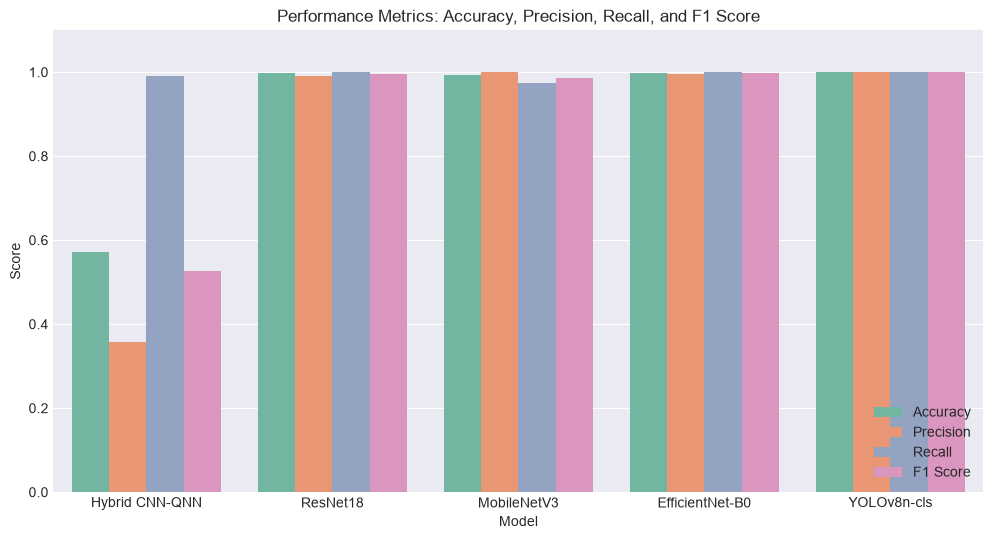

In [9]:
df_melted = df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'], 
                    var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Performance Metrics: Accuracy, Precision, Recall, and F1 Score')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.savefig('performance_metrics_grouped.png', dpi=300, bbox_inches='tight')
plt.show()

## 1. Core Comparison Graphs
Line graphs for training accuracy, and bar charts for FPS, Model Complexity, and Final Accuracy.

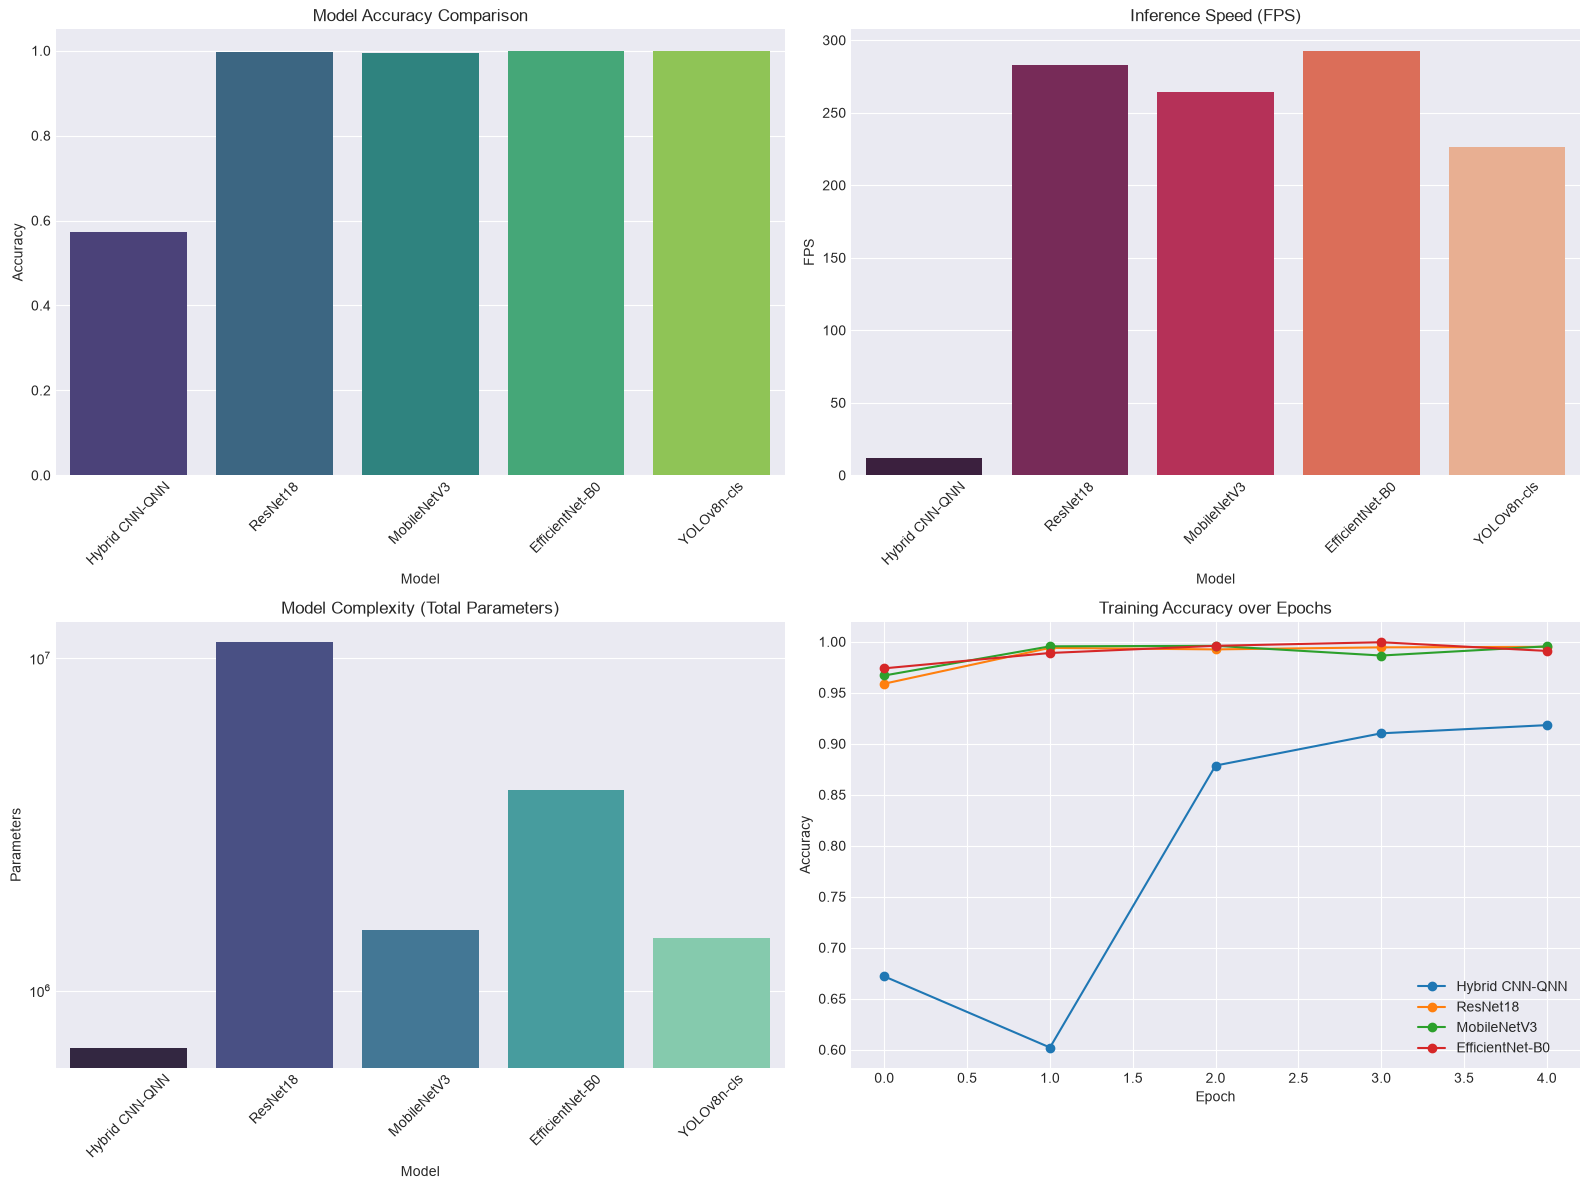

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=df, x='Model', y='Accuracy', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title("Model Accuracy Comparison")
axes[0, 0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='Model', y='FPS', ax=axes[0, 1], palette='rocket')
axes[0, 1].set_title("Inference Speed (FPS)")
axes[0, 1].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='Model', y='Parameters', ax=axes[1, 0], palette='mako')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title("Model Complexity (Total Parameters)")
axes[1, 0].tick_params(axis='x', rotation=45)

for name, res in results.items():
    if name != "YOLOv8n-cls":
        axes[1, 1].plot(res['history']['acc'], marker='o', label=name)
axes[1, 1].set_title("Training Accuracy over Epochs")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("core_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Radar Chart
Shows multivariate performance. A larger shape means a better overall model.

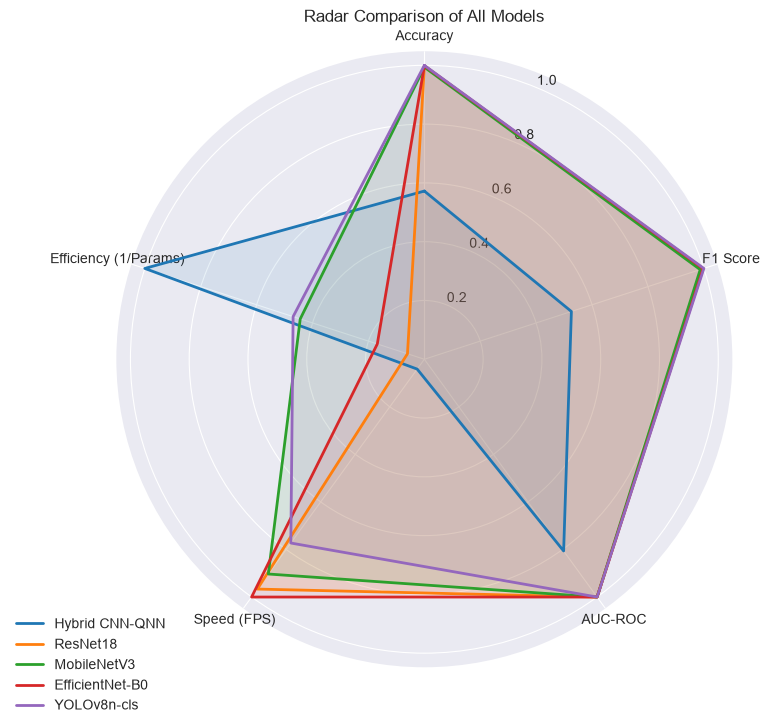

In [11]:
from math import pi

categories = ['Accuracy', 'F1 Score', 'AUC-ROC', 'Speed (FPS)', 'Efficiency (1/Params)']
N = len(categories)

df_radar = df.copy()
df_radar['Speed (FPS)'] = df['FPS'] / df['FPS'].max()
df_radar['Efficiency (1/Params)'] = (1/df['Parameters']) / (1/df['Parameters']).max()

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories)

for i, row in df_radar.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'])
    ax.fill(angles, values, alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title("Radar Comparison of All Models")
plt.savefig("radar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. ROC & Precision-Recall Curves
Comparing True Positive Rates against False Positives.

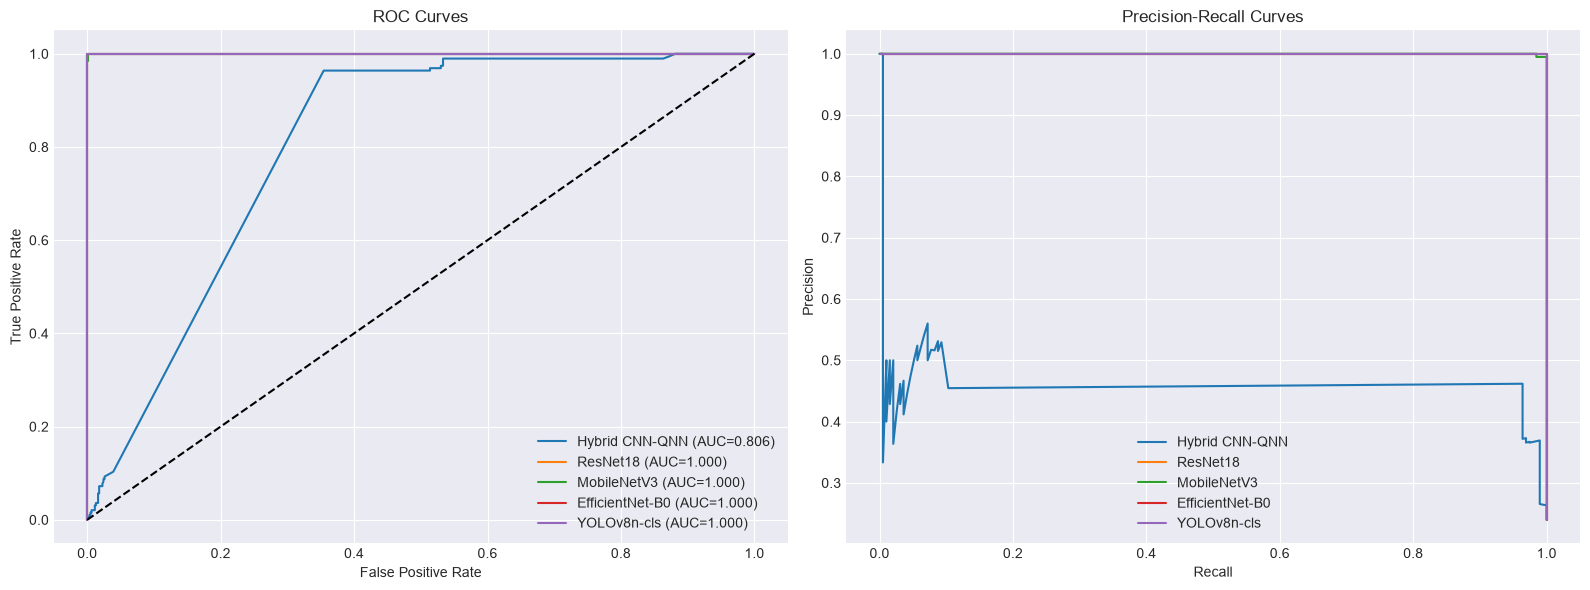

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(res['labels'], res['probs']):.3f})")
    
    prec, rec, _ = precision_recall_curve(res['labels'], res['probs'])
    ax2.plot(rec, prec, label=name)

ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend()

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves')
ax2.legend()

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Confusion Matrices
Side-by-side comparison of misclassifications.

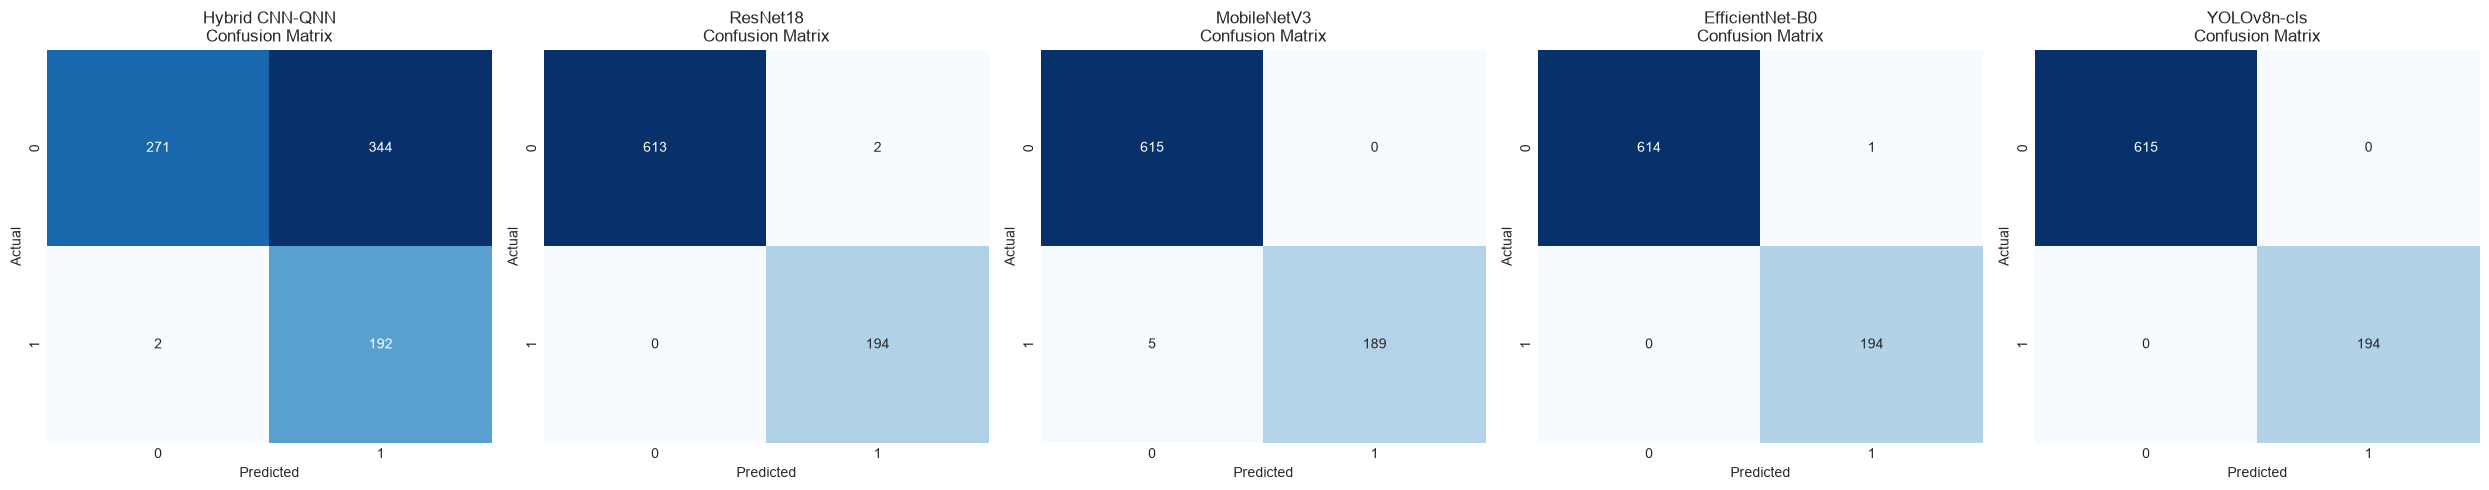

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name}\nConfusion Matrix")
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Model Agreement (Correlation Heatmap) & Critical Difference
The heatmap shows how similarly the models make predictions. A score of 1.0 means they predicted the exact same classes on the test set.

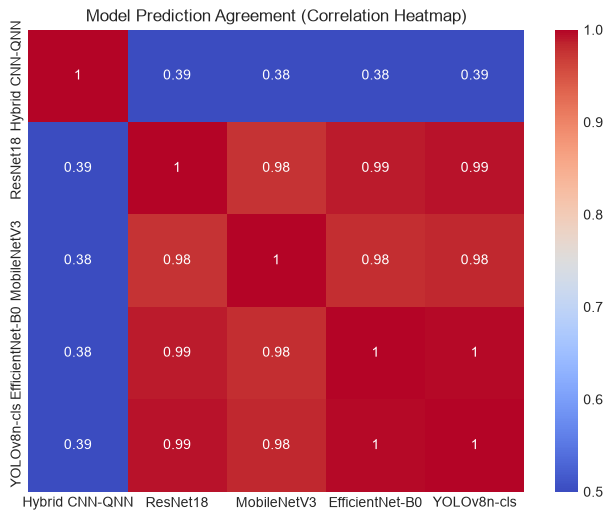

In [14]:
preds_df = pd.DataFrame({name: res['preds'] for name, res in results.items()})
plt.figure(figsize=(8, 6))
sns.heatmap(preds_df.corr(), annot=True, cmap='coolwarm', vmin=0.5, vmax=1.0)
plt.title("Model Prediction Agreement (Correlation Heatmap)")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. SHAP Values (Feature Importance)
Highlights which pixels drove the model's decision.

In [15]:
print("Computing SHAP values for Classical ResNet18 (as QNN gradients are unsupported by DeepExplainer)...")
background = next(iter(train_loader))[0][:100].to(device)
test_images = next(iter(test_loader))[0][:5].to(device)

e = shap.DeepExplainer(resnet, background)
shap_values = e.shap_values(test_images)
shap_numpy = [np.swapaxes(np.swapaxes(s, 1, -1), 1, 2) for s in shap_values]
test_numpy = np.swapaxes(np.swapaxes(test_images.cpu().numpy(), 1, -1), 1, 2)

shap.image_plot(shap_numpy, -test_numpy, show=False)
import matplotlib.pyplot as plt
plt.savefig("shap_values.png", dpi=300, bbox_inches="tight")
plt.show()

Computing SHAP values for Classical ResNet18 (as QNN gradients are unsupported by DeepExplainer)...


RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.